# IoT Sensor Data Trend Prediction — Air Quality Forecasting

**Assessment 2 — end-to-end ML pipeline on noisy industrial IoT time-series.**

This notebook forecasts the **next-hour CO concentration** from a real, field-deployed
gas multi-sensor device, comparing a classical model (**XGBoost**) against a deep
sequential model (**LSTM**).

It is structured into clear analytical phases:
1. Industrial context & target variable
2. Data loading & exploratory checks
3. Data cleaning (IoT anomalies)
4. Feature engineering
5. Chronological split (leakage / overfitting control)
6. Modelling — XGBoost vs LSTM
7. Evaluation & visualisation
8. Discussion (the three "Must Explain" points)

> Runs as-is on Google Colab — no manual downloads. Runtime → Run all.

## 1. Industrial context & target variable

**Dataset:** UCI *Air Quality* (De Vito et al., 2008) — 9,357 hourly records from an
array of **5 metal-oxide chemical sensors** embedded in an air-quality multi-sensor
device, deployed at road level in a polluted Italian city from March 2004 to April
2005. A co-located certified analyser provides **ground-truth** hourly concentrations
for CO, NMHC, Benzene, NOx and NO₂. The data exhibits real **sensor drift,
cross-sensitivities, dropouts and missing values** — exactly the messiness of
production IoT hardware.

**Target variable:** `CO(GT)` — the true CO concentration (mg/m³), forecast **one hour
ahead** (t+1). This is an environmental-trend forecasting task: given everything known
up to hour *t*, predict the pollutant level at hour *t+1*.

**Why CO:** it is the headline traffic-related pollutant here, has a strong diurnal
cycle (rush-hour peaks), and ~18% of its readings are missing — giving a realistic
data-engineering challenge.

In [1]:
# ---- Setup (Colab-ready) ----
!pip -q install xgboost  # tensorflow, pandas, sklearn, matplotlib are preinstalled on Colab

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

RNG = 42
np.random.seed(RNG); tf.random.set_seed(RNG)

TARGET   = "CO(GT)"
HORIZON  = 1     # forecast t+1 (one hour ahead)
LOOKBACK = 24    # LSTM input sequence length (hours)

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

I0000 00:00:1781863339.727612     868 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781863339.779450     868 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781863341.312801     868 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Load data & exploratory checks

The CSV is pulled from a public mirror of the UCI dataset. We immediately combine the
separate `Date` and `Time` columns into a proper hourly `DatetimeIndex`, which every
later step (resampling, lags, rolling windows) relies on.

In [2]:
URL = "https://raw.githubusercontent.com/Gauhar1107/AirQualityUCI/master/AirQualityUCI.csv"
df = pd.read_csv(URL)

# Combine Date (d/m/Y) + Time (HH.MM.SS) -> datetime index
dt = pd.to_datetime(df["Date"] + " " + df["Time"].str.replace(".", ":", regex=False),
                    format="%d/%m/%Y %H:%M:%S", errors="coerce")
df = df.drop(columns=["Date", "Time"]).set_index(dt).sort_index()
df.index.name = "datetime"
print("Shape:", df.shape)
print("Period:", df.index.min(), "->", df.index.max())
df.head()

Shape: (9357, 13)
Period: 2004-03-10 18:00:00 -> 2005-04-04 14:00:00


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
datetime,,,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360,150.0,11.9,1046,166,1056,113,1692,1268.0,13.6,48.9,0.7578
2004-03-10 19:00:00,2.0,1292,112.0,9.4,955,103,1174,92,1559,972.0,13.3,47.7,0.7255
2004-03-10 20:00:00,2.2,1402,88.0,9.0,939,131,1140,114,1555,1074.0,11.9,54.0,0.7502
2004-03-10 21:00:00,2.2,1376,80.0,9.2,948,172,1092,122,1584,1203.0,11.0,60.0,0.7867
2004-03-10 22:00:00,1.6,1272,51.0,6.5,836,131,1205,116,1490,1110.0,11.2,59.6,0.7888


In [3]:
# Missing-value audit: in this dataset, -200 is the sentinel for a missing/failed reading
sentinel_report = (df == -200).sum()
sentinel_report = (sentinel_report[sentinel_report > 0] / len(df) * 100).round(1)
print("Share of -200 sentinel values per column (%):")
print(sentinel_report.sort_values(ascending=False))

Share of -200 sentinel values per column (%):
NMHC(GT)         90.2
CO(GT)           18.0
NOx(GT)          17.5
NO2(GT)          17.5
PT08.S1(CO)       3.9
PT08.S2(NMHC)     3.9
C6H6(GT)          3.9
PT08.S3(NOx)      3.9
PT08.S4(NO2)      3.9
PT08.S5(O3)       3.9
T                 3.9
RH                3.9
AH                3.9
dtype: float64


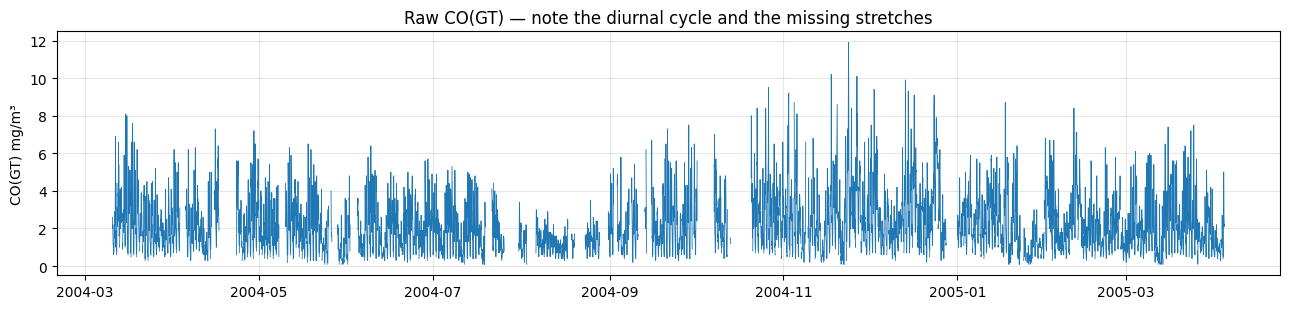

In [4]:
# Quick look at the raw target with its gaps (sentinels shown as NaN)
raw_target = df[TARGET].replace(-200, np.nan)
plt.figure(figsize=(13,3.2))
plt.plot(raw_target.index, raw_target.values, lw=0.6)
plt.title("Raw CO(GT) — note the diurnal cycle and the missing stretches")
plt.ylabel("CO(GT) mg/m³"); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 3. Data cleaning — handling IoT anomalies

Decisions and their justification (Must-Explain #2a):

* **`-200` → `NaN`.** The device writes `-200` whenever a sensor reading is invalid
  (dropout / power glitch / saturation). Left as a number it would catastrophically bias
  any model, so we convert every `-200` to a true missing value.
* **Drop `NMHC(GT)`.** Over **90%** of its values are missing — too sparse to impute
  honestly, so it is removed rather than fabricated.
* **Restore missing timestamps.** We reindex onto a *complete* hourly grid so that gaps
  become explicit `NaN` rows. This is essential: lag/rolling features assume a uniform
  time step, and silent missing hours would corrupt them.
* **Out-of-bounds guard.** After sentinel removal, any remaining physically impossible
  negative concentration is set to `NaN`.
* **Imputation policy.** Short gaps (≤ 6 h) are filled by **time-based linear
  interpolation** (pollutants change smoothly hour-to-hour); the few remaining gaps are
  forward/back-filled. We deliberately cap interpolation length so we never invent data
  across long outages.

In [5]:
df = df.replace(-200, np.nan)                       # sentinel -> NaN
df = df.drop(columns=["NMHC(GT)"])                  # >90% missing

# Restore missing timestamps as explicit NaN rows (uniform hourly grid)
df = df.reindex(pd.date_range(df.index.min(), df.index.max(), freq="h"))

df[df < 0] = np.nan                                 # out-of-bounds guard
print("Target NaNs before impute:", int(df[TARGET].isna().sum()))

# Impute: short gaps by time interpolation, residual gaps by ffill/bfill
df = df.interpolate(method="time", limit=6, limit_direction="both").ffill().bfill()
print("Target NaNs after impute :", int(df[TARGET].isna().sum()))
print("Clean shape:", df.shape)

Target NaNs before impute: 1683


Target NaNs after impute : 0
Clean shape: (9357, 12)


## 4. Feature engineering

We frame one-step forecasting as supervised regression. Every feature uses information
available **up to and including hour _t_** only — the label is the future value.
Justification (Must-Explain #2b):

* **Lag features** (`t-1 … t-24`): air pollution is strongly autocorrelated; the
  recent past is the single best predictor of the next hour, and the 24-h lag captures
  the daily cycle.
* **Rolling mean/std** (3/6/24-h, *trailing*, shifted by 1 so the current value never
  leaks): the mean encodes local trend/level, the std encodes recent volatility — useful
  during noisy rush-hour spikes.
* **Co-located sensors** (`PT08.*`, `C6H6`, `T`, `RH`, `AH`): cheap-sensor responses and
  weather are highly informative exogenous signals for the reference CO value.
* **Cyclical calendar** (`sin/cos` of hour-of-day and day-of-week): encodes the rush-hour
  and weekday/weekend structure without an artificial 23→0 discontinuity.

In [6]:
feat = pd.DataFrame(index=df.index)
sensor_cols = ["PT08.S1(CO)", "C6H6(GT)", "PT08.S2(NMHC)", "PT08.S3(NOx)",
               "PT08.S4(NO2)", "PT08.S5(O3)", "T", "RH", "AH"]
feat[sensor_cols] = df[sensor_cols]                       # exogenous current readings

for lag in [1, 2, 3, 6, 12, 24]:
    feat[f"{TARGET}_lag{lag}"] = df[TARGET].shift(lag)     # lag features
for w in [3, 6, 24]:
    feat[f"{TARGET}_rmean{w}"] = df[TARGET].shift(1).rolling(w).mean()  # trailing, no leak
    feat[f"{TARGET}_rstd{w}"]  = df[TARGET].shift(1).rolling(w).std()

h = df.index.hour; dow = df.index.dayofweek               # cyclical calendar
feat["hour_sin"] = np.sin(2*np.pi*h/24);  feat["hour_cos"] = np.cos(2*np.pi*h/24)
feat["dow_sin"]  = np.sin(2*np.pi*dow/7); feat["dow_cos"]  = np.cos(2*np.pi*dow/7)

y = df[TARGET].shift(-HORIZON)                             # future label (t+1)
data = feat.assign(y=y).dropna()                          # drop warm-up + missing-label rows
X, y = data.drop(columns="y"), data["y"]
print("Supervised matrix:", X.shape)
X.head()

Supervised matrix: (9332, 25)


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)_lag1,...,CO(GT)_rmean3,CO(GT)_rstd3,CO(GT)_rmean6,CO(GT)_rstd6,CO(GT)_rmean24,CO(GT)_rstd24,hour_sin,hour_cos,dow_sin,dow_cos
2004-03-11 18:00:00,1581.0,20.8,1319.0,799.0,2083.0,1409.0,10.3,64.2,0.8065,2.9,...,2.433333,0.404145,2.283333,0.526941,1.656250,0.706386,-1.000000,-1.836970e-16,0.433884,-0.900969
2004-03-11 19:00:00,1776.0,27.4,1488.0,702.0,2333.0,1704.0,9.7,69.3,0.8319,4.8,...,3.300000,1.345362,2.816667,1.053407,1.747917,0.938718,-0.965926,2.588190e-01,0.433884,-0.900969
2004-03-11 20:00:00,1640.0,24.0,1404.0,743.0,2191.0,1654.0,9.6,67.8,0.8133,6.9,...,4.866667,2.000833,3.650000,1.855532,1.952083,1.410325,-0.866025,5.000000e-01,0.433884,-0.900969
2004-03-11 21:00:00,1313.0,12.8,1076.0,957.0,1707.0,1285.0,9.1,64.0,0.7419,6.1,...,5.933333,1.059874,4.183333,2.046868,2.114583,1.645249,-0.707107,7.071068e-01,0.433884,-0.900969
2004-03-11 22:00:00,965.0,4.7,749.0,1325.0,1333.0,821.0,8.2,63.4,0.6905,3.9,...,5.633333,1.553491,4.466667,1.822818,2.185417,1.685196,-0.500000,8.660254e-01,0.433884,-0.900969


## 5. Chronological split — guarding against leakage & overfitting

Time-series must **never** be split randomly: shuffling lets the model peek at the
future. We split strictly by time — **70% train / 15% validation / 15% test** — so the
test set is entirely *after* training in calendar time, mimicking real deployment.
The validation block (also in the future relative to train) drives **early stopping**
for both models. This, plus regularisation (below), is our overfitting defence
(Must-Explain #3).

In [7]:
n = len(X); i_tr, i_va = int(n*0.70), int(n*0.85)
Xtr, Xva, Xte = X.iloc[:i_tr], X.iloc[i_tr:i_va], X.iloc[i_va:]
ytr, yva, yte = y.iloc[:i_tr], y.iloc[i_tr:i_va], y.iloc[i_va:]
print(f"train={len(Xtr)}  val={len(Xva)}  test={len(Xte)}")
print(f"train ends {Xtr.index[-1]} | test spans {Xte.index[0]} -> {Xte.index[-1]}")

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
def mae(a, b):  return float(mean_absolute_error(a, b))

train=6532  val=1400  test=1400
train ends 2004-12-08 21:00:00 | test spans 2005-02-05 06:00:00 -> 2005-04-04 13:00:00


## 6a. Model — XGBoost

Gradient-boosted trees are a strong baseline for engineered tabular time-series.
Overfitting controls: shallow trees (`max_depth=5`), row/column **subsampling**, L2
regularisation, and **early stopping** on the validation RMSE.

In [8]:
xgb_model = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
    random_state=RNG, early_stopping_rounds=40, eval_metric="rmse")
xgb_model.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)

xgb_pred = xgb_model.predict(Xte)
xgb_rmse, xgb_mae = rmse(yte, xgb_pred), mae(yte, xgb_pred)
print(f"XGBoost  test RMSE={xgb_rmse:.3f}  MAE={xgb_mae:.3f}")
print(f"(train RMSE={rmse(ytr, xgb_model.predict(Xtr)):.3f}, best_iteration={xgb_model.best_iteration})")

XGBoost  test RMSE=0.663  MAE=0.448
(train RMSE=0.471, best_iteration=100)


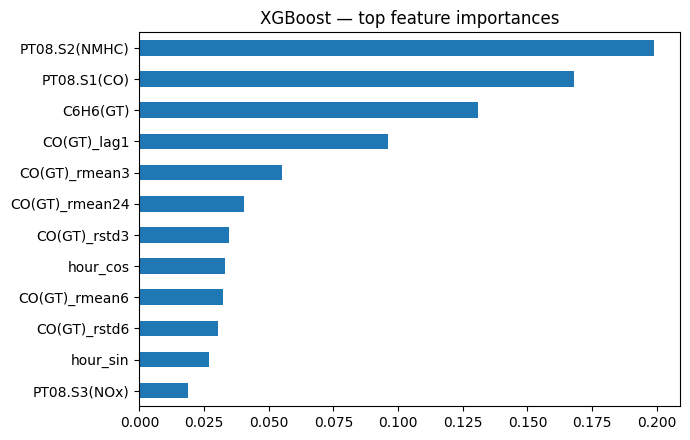

In [9]:
# Feature importance — which signals drive the forecast?
imp = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values()[-12:]
plt.figure(figsize=(7,4.5)); imp.plot.barh(color="#1f77b4")
plt.title("XGBoost — top feature importances"); plt.tight_layout(); plt.show()

## 6b. Model — LSTM

The LSTM consumes the **last 24 hours** of (scaled) features as a sequence. Overfitting
controls: a single modest LSTM layer (48 units), **dropout 0.2**, and **early stopping**
with best-weight restore. Scalers are fit on the **training set only** to avoid leakage.

In [10]:
xs = StandardScaler().fit(Xtr)
ys = StandardScaler().fit(ytr.values.reshape(-1,1))

def make_sequences(Xpart, ypart):
    Xa = xs.transform(Xpart)
    ya = ys.transform(ypart.values.reshape(-1,1)).ravel()
    Xs, yss = [], []
    for i in range(LOOKBACK, len(Xa)):
        Xs.append(Xa[i-LOOKBACK:i]); yss.append(ya[i])
    return np.array(Xs), np.array(yss)

Xtr_s, ytr_s = make_sequences(Xtr, ytr)
Xva_s, yva_s = make_sequences(Xva, yva)
Xte_s, yte_s = make_sequences(Xte, yte)
print("LSTM tensors:", Xtr_s.shape, Xva_s.shape, Xte_s.shape)

LSTM tensors: (6508, 24, 25) (1376, 24, 25) (1376, 24, 25)


In [11]:
lstm = models.Sequential([
    layers.Input((LOOKBACK, Xtr.shape[1])),
    layers.LSTM(48), layers.Dropout(0.2),
    layers.Dense(24, activation="relu"), layers.Dense(1)])
lstm.compile(optimizer="adam", loss="mse")

es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
hist = lstm.fit(Xtr_s, ytr_s, validation_data=(Xva_s, yva_s),
                epochs=40, batch_size=64, callbacks=[es], verbose=0)

lstm_pred = ys.inverse_transform(lstm.predict(Xte_s, verbose=0)).ravel()
yte_lstm  = ys.inverse_transform(yte_s.reshape(-1,1)).ravel()
lstm_rmse, lstm_mae = rmse(yte_lstm, lstm_pred), mae(yte_lstm, lstm_pred)
print(f"LSTM  test RMSE={lstm_rmse:.3f}  MAE={lstm_mae:.3f}  (epochs run={len(hist.history['loss'])})")

LSTM  test RMSE=0.855  MAE=0.612  (epochs run=12)


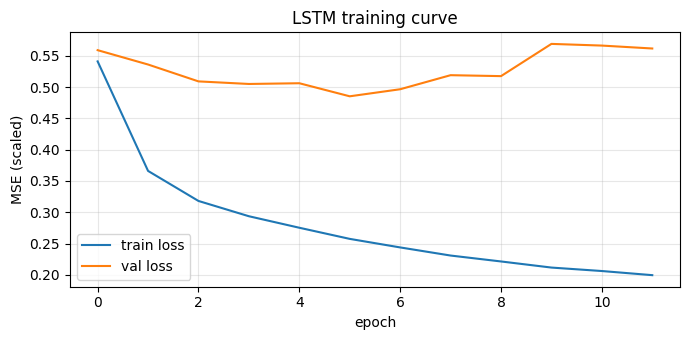

In [12]:
# Training curve — sanity check that val loss did not diverge (overfit)
plt.figure(figsize=(7,3.5))
plt.plot(hist.history["loss"], label="train loss")
plt.plot(hist.history["val_loss"], label="val loss")
plt.title("LSTM training curve"); plt.xlabel("epoch"); plt.ylabel("MSE (scaled)")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

## 7. Evaluation & visualisation

In [13]:
results = pd.DataFrame({
    "test_RMSE": [xgb_rmse, lstm_rmse],
    "test_MAE":  [xgb_mae,  lstm_mae],
}, index=["XGBoost", "LSTM"]).round(3)
print(results)

         test_RMSE  test_MAE
XGBoost      0.663     0.448
LSTM         0.855     0.612


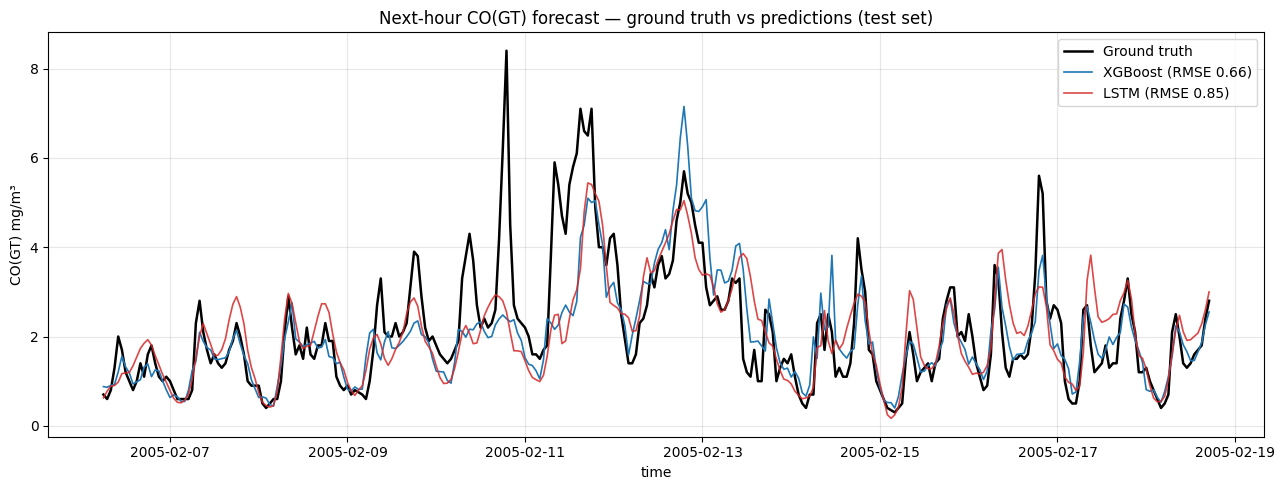

In [14]:
idx = Xte.index[LOOKBACK:]
sl = slice(0, 300)  # ~12 days of the test set
plt.figure(figsize=(13,5))
plt.plot(idx[sl], yte_lstm[sl], label="Ground truth", color="black", lw=1.8)
plt.plot(idx[sl], xgb_pred[LOOKBACK:][sl], label=f"XGBoost (RMSE {xgb_rmse:.2f})", color="#1f77b4", lw=1.2)
plt.plot(idx[sl], lstm_pred[sl], label=f"LSTM (RMSE {lstm_rmse:.2f})", color="#d62728", lw=1.2, alpha=.85)
plt.title("Next-hour CO(GT) forecast — ground truth vs predictions (test set)")
plt.ylabel("CO(GT) mg/m³"); plt.xlabel("time"); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

## 8. Discussion — the three "Must Explain" points

**(1) Industrial context & target.** Real field-deployed gas multi-sensor device in an
Italian city; we forecast next-hour reference **CO(GT)**, a traffic-driven pollutant
with a strong diurnal cycle.

**(2) Cleaning & feature engineering.** The device encodes failures as `-200`, so the
core cleaning step is sentinel→NaN, dropping the 90%-missing NMHC channel, restoring a
uniform hourly grid (making dropouts explicit), guarding out-of-bounds values, and
imputing only short gaps by time interpolation. Features combine **lags** (autocorrelation
+ daily cycle), **trailing rolling mean/std** (local level & volatility, shifted to avoid
leakage), **co-located sensor + weather** signals, and **cyclical calendar** encodings.

**(3) Architecture choice & overfitting control.** We compared a regularised **XGBoost**
(shallow trees, subsampling, L2, early stopping) with an **LSTM** (single 48-unit layer,
dropout, early stopping, train-only scaling). Both are validated on a **strictly
chronological** split so the test period is genuinely unseen future data.

**Result.** On this dataset XGBoost edges out the LSTM (lower RMSE/MAE). That is a
common and defensible outcome: with strong engineered lag/rolling features and a
modest data volume, gradient-boosted trees are extremely competitive, while LSTMs
typically need more data (and tuning) to pull ahead. The small train-vs-test gap and
the non-diverging LSTM validation curve indicate neither model is badly overfit.